In [1]:
from save_frame_from_file import iter_frame_metrics_rows
from streaming_regime import (
    FinalRegimeBreakDetector,
    iter_metrics_with_jump_ratios,
    make_row_regime_break_detector,
)
from utils import get_frames_estimate
from vidfile_iterator import get_frame_iterator_from_file, get_frames_from_iterator
import pathlib
import pandas as pd
import numpy as np 

In [2]:
filename = r'C:\users\assaf\Desktop\Temporary\Video_With_Noise_2.mkv'
print(filename)


C:\users\assaf\Desktop\Temporary\Video_With_Noise_2.mkv


In [3]:
def locate_noise_with_metrics(video_path):
    """Run the locate-noise pipeline and collect metrics into a DataFrame.

    Returns
    -------
    last_break: RegimeBreak | None
        Output of the regime-break detector (may be None).
    df: pandas.DataFrame
        DataFrame with one row per frame, containing both the original
        frame metrics and the derived jump-ratio columns.
    """

    total_frames, fps = get_frames_estimate(video_path)

    frame_iterator = get_frame_iterator_from_file(video_path)
    frames = get_frames_from_iterator(frame_iterator)

    # 1) Compute frame-level metrics (no inner tqdm here).
    rows = iter_frame_metrics_rows(frames, total_frames, fps, use_tqdm=False)

    # 2) Enrich rows with short/long stats + jump ratio on laplacian_variance.
    # enriched_rows = iter_metrics_with_jump_ratios(
    #     rows, 
    #     ewm_span=1000)

    enriched_rows = iter_metrics_with_jump_ratios(
        rows,
        numerator_mode="percentile",   # switch from top-half mean
        percentile_q=0.75,             # 75th percentile
    )

    # 3) Track the last upward crossing of a jump-ratio threshold on those rows.
    det = make_row_regime_break_detector(1.5, value_key="lap_jump_ratio", frame_key="frame")

    collected_rows = []
    for row in enriched_rows:
        det.consume(row)
        collected_rows.append(row)

    last_break = det.result()
    df = pd.DataFrame(collected_rows)
    return last_break, df

In [4]:
last_break, metrics_df = locate_noise_with_metrics(filename)
print(last_break)
display(metrics_df.head())

Testing modern decoding in vidfile_iterator.py with: C:\users\assaf\Desktop\Temporary\Video_With_Noise_2.mkv
None


,timestamp,frame,mean,local_entropy,laplacian_variance,laplacian_variance_short,laplacian_variance_long,laplacian_variance_jump_ratio
0,0.00,0,127.777905,1.555597,23.844707,NaN,23.844707,NaN
1,0.02,1,126.644663,1.561457,22.515509,NaN,23.842051,NaN
2,0.04,2,126.539906,1.605262,23.630892,NaN,23.841630,NaN
3,0.06,3,125.731398,1.626487,24.370617,NaN,23.842687,NaN
4,0.08,4,125.726481,1.624164,23.434533,NaN,23.841871,NaN


In [5]:
display(metrics_df)

,timestamp,frame,mean,local_entropy,laplacian_variance,laplacian_variance_short,laplacian_variance_long,laplacian_variance_jump_ratio
0,0.00,0,127.777905,1.555597,23.844707,NaN,23.844707,NaN
1,0.02,1,126.644663,1.561457,22.515509,NaN,23.842051,NaN
2,0.04,2,126.539906,1.605262,23.630892,NaN,23.841630,NaN
3,0.06,3,125.731398,1.626487,24.370617,NaN,23.842687,NaN
4,0.08,4,125.726481,1.624164,23.434533,NaN,23.841871,NaN
...,...,...,...,...,...,...,...,...
578,11.56,578,68.225725,2.059794,51.597609,105.238539,63.084481,1.668216
579,11.58,579,70.728552,2.180689,115.944788,109.776323,63.190096,1.737239
580,11.60,580,69.722966,1.931841,37.378789,105.238539,63.138525,1.666788
581,11.62,581,69.063581,1.891542,41.315714,100.044521,63.094923,1.585619


In [6]:
print(list(metrics_df.columns))

['timestamp', 'frame', 'mean', 'local_entropy', 'laplacian_variance', 'laplacian_variance_short', 'laplacian_variance_long', 'laplacian_variance_jump_ratio']


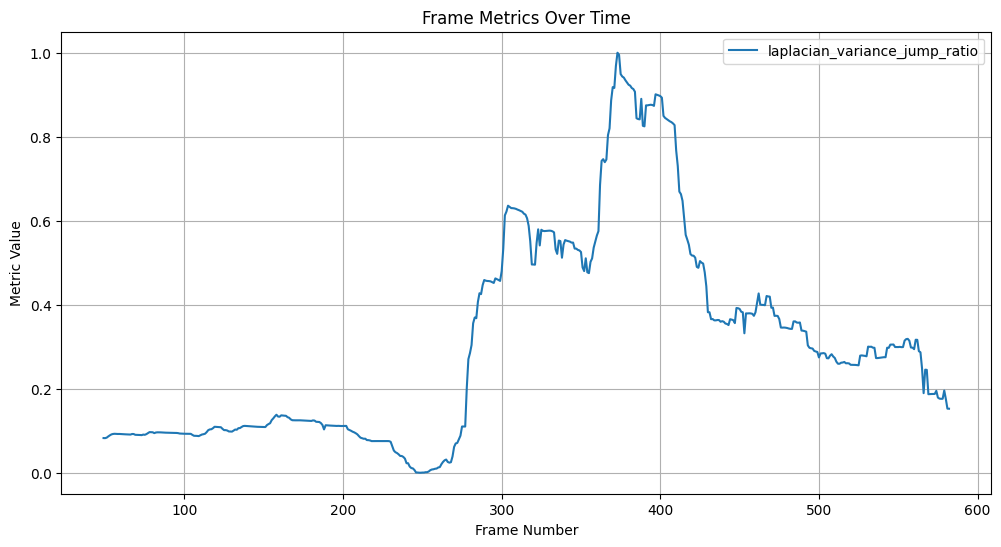

In [7]:
# display graphs of all metrics, x axis being the frame number, and y axis being the metric value, all in one graph, with a legend for each metric

do_not_display = {'frame', 'frame_no', 'timestamp', 'combined_entropy'}
all_metrics = set(metrics_df.columns) - set(do_not_display)
all_metrics = [
    # 'hist_entropy',
    # 'edge_density',
    # 'temporal_entropy',
    # 'local_entropy',
    # 'laplacian_variance',
    # 'lap_short',
    # 'lap_long',
    'laplacian_variance_jump_ratio'
]

all_metrics = sorted(all_metrics)  # Sort metrics alphabetically for consistent order in the legend
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

for metric in all_metrics:
    metric_values = metrics_df[metric]
    metric_values_normalized = (metric_values - np.min(metric_values)) / (np.max(metric_values) - np.min(metric_values))
    plt.plot(metrics_df['frame'], metric_values_normalized, label=metric) 

plt.xlabel('Frame Number')
plt.ylabel('Metric Value')
plt.title('Frame Metrics Over Time')
plt.legend()
plt.grid()
plt.show()
